## Introducción

objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. 
trabajaron los datos reales de TomTom Traffic Index y OECD Cities, para limpiar, combinar y analizar con el fin de identificar en qué ciudades conviene invertir en infraestructura de transporte.

## Paso 1: Cargar y explorar
### 1.1 Carga de datos y vista rápida

Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [83]:
# importar librerías
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [84]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [85]:
# mostrar las primeras 5 filas de traffic
traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [86]:
# mostrar las primeras 5 filas de eco
eco.head(5)

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"



---

## Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Observar las columnas que necesiten limpieza y estandarizar los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

In [87]:
# Examinar la estructura de traffic
traffic.info()
traffic.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTC` son de tipo Object, que hacen referencia al tiempo, será necesaria su conversión
- No muestra nulos en este pequeño resumen.
- el dataset tiene 12 columnas con 1004464 entradas.

In [88]:
# Examinar la estructura de eco
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %` estan en otro tipo de dato, se necesita convertir para poder realizar mediciones.
- EL data set tiene 7 columnas con 30 entradas.
- No muestra nulos.

### 2.2 Renombrar columnas
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

In [89]:
# Estandarizar los nombres de las columnas de traffic
#tu código aquí
traffic = traffic.rename( columns={
    'Country':'country',
    'City':'city',
    'UpdateTimeUTC':'update_time_utc',
 'JamsDelay': 'jams_delay',
 'TrafficIndexLive': 'traffic_index_live',
 'JamsLengthInKms': 'jams_length_in_kms',
 'JamsCount':'jams_count',
 'TrafficIndexWeekAgo':'traffic_index_week_ago',
 'UpdateTimeUTCWeekAgo':'update_time_utc_week_ago',
 'TravelTimeLivePer10KmsMins':'travel_time_live_per_10kms_mins',
 'TravelTimeHistoricPer10KmsMins':'travel_time_historic_per_10kms_mins',  
 'MinsDelay':'mins_delay',
}   
)
# verificar cambios
print(traffic.columns)

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins',
       'travel_time_historic_per_10kms_mins', 'mins_delay'],
      dtype='object')


In [90]:
# Estandarizar los nombres de las columnas de eco
#tu código aquí
eco= eco.rename(columns={ 
    'Year':'year',
 'City': 'city',   
 'Country':'country',    
 'City GDP/capita':'city_gdp_capita',
 'Unemployment %':'unemployment_pct', 
 'PM2.5 (μg/m³)':'pm25',
 'Population (M)':'population_m'
})
# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

In [91]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] =pd.to_datetime(traffic['update_time_utc'],errors='coerce',utc='True')
traffic['update_time_utc_week_ago'] =pd.to_datetime(traffic['update_time_utc_week_ago'],errors='coerce',utc='True')

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                               Non-Null Count    Dtype              
---  ------                               --------------    -----              
 0   country                              1004464 non-null  object             
 1   city                                 1004464 non-null  object             
 2   update_time_utc                      1004464 non-null  datetime64[ns, UTC]
 3   jams_delay                           1004464 non-null  float64            
 4   traffic_index_live                   1004464 non-null  float64            
 5   jams_length_in_kms                   1004464 non-null  float64            
 6   jams_count                           1004464 non-null  float64            
 7   traffic_index_week_ago               1004464 non-null  float64            
 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns, UTC]
 9   tr

In [92]:
# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_capita'] =(eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float))
eco['unemployment_pct'] =(eco['unemployment_pct'].astype(str).str.replace('%', '').str.replace(',', '.').astype(float))
eco['population_m'] =(eco['population_m'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float))

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco['population_m']* 1000000

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0



---

## Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024
Identificar el año de cada registro y mantener solo los registros del 2024.

In [93]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001000+00:00,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30+00:00,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00+00:00,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001000+00:00,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30+00:00,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30+00:00,8.196278,8.196510,-0.000232,2025


In [94]:
# Filtra los registros del año 2024

traffic_2024 = traffic[traffic['year']== 2024].copy()
eco_2024 = eco[eco['year']== 2024].copy()
#print(traffic['year'].unique())
#print(eco['year'].unique())
# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30+00:00,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001000+00:00,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30+00:00,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30+00:00,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30+00:00,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30+00:00,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001000+00:00,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001000+00:00,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00+00:00,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00+00:00,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0



---

## Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcular los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

In [95]:
# Calcular los  promedios de trafico por ciudad, país y año
grupo=['city','country', 'year']
traffic_city_year_2024 = traffic_2024.groupby(grupo,dropna=False).agg(
    {
        'jams_delay':'mean',
        'traffic_index_live':'mean',
        'jams_length_in_kms':'mean',
        'jams_count':'mean',
        'mins_delay':'mean',
        'travel_time_live_per_10kms_mins':'mean',
        'travel_time_historic_per_10kms_mins':'mean',
    }
).reset_index()

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945



Ahora que ya tienes los promedios anuales por ciudad, es momento de **observarlos** con atención.
- ¿Cuál crees que tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?

In [96]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es la Ciudad de México(Mexico city)


---

## Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

In [103]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_in_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_historic_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small,eco_2024_small,on=['city','year'],how= 'inner')

# Mostrar las primeras 5 filas
print(merged.head(5))

             city country  year   jams_delay  traffic_index_live  \
0  belo-horizonte     BRA  2024   263.047879           19.428946   
1          bogota     COL  2024  1141.552364           37.614273   
2        brasilia     BRA  2024   101.576326           11.258220   
3    buenos-aires     ARG  2024   571.089593           17.756012   
4        curitiba     BRA  2024   183.469274           14.954545   

   jams_length_in_kms  jams_count  mins_delay  \
0           44.038129   68.805422    0.487228   
1          140.893564  230.566550    1.699628   
2           18.337133   27.280140    0.193442   
3          100.287844  137.359860    0.416566   
4           30.050044   46.898164    0.139965   

   travel_time_live_per_10kms_mins  travel_time_historic_per_10kms_mins  \
0                        18.304538                            17.817311   
1                        24.992185                            23.292557   
2                        13.338658                            13.145216


---

## Paso 6: Visualización y análisis de relaciones

con el dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudan a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

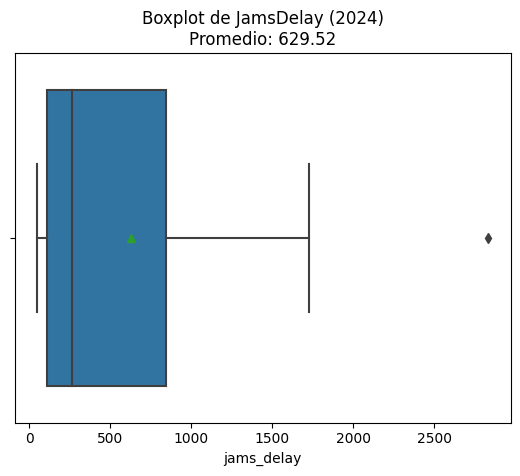

In [105]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico
sns.boxplot(data=merged,x='jams_delay',showmeans=True)
# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()


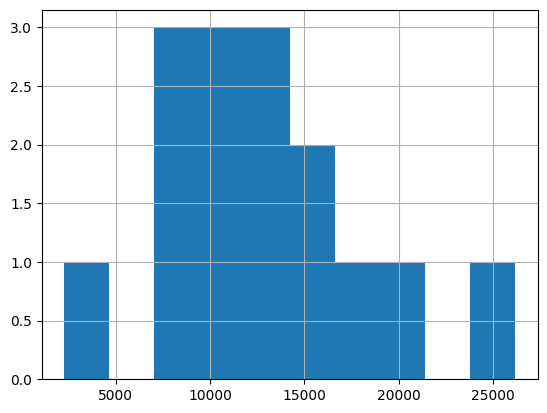

In [108]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
merged['city_gdp_capita'].hist()
plt.show()

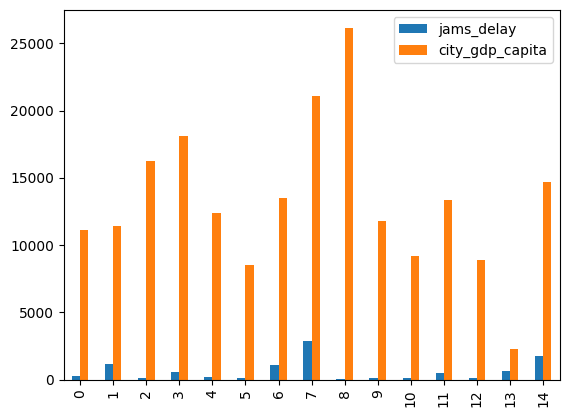

In [110]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
merged.plot(kind='bar', y=['jams_delay', 'city_gdp_capita'])
plt.xticks(rotation=90)
plt.show()

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?

No existe una relación clara,
ya que hay ciudades con un elevado PIB que presentan un congestión de trafico alta,sin embargo ,las que tienen menor PIB presentan menos trafico que aquellas que tienen un PIB promedio arriba de 10,000.


---

## Paso 7: Exportar y documentar resultados

### 7.1 Guardar dataset final

Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.



In [112]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

print(merged['city'].unique())

['belo-horizonte' 'bogota' 'brasilia' 'buenos-aires' 'curitiba'
 'fortaleza' 'lima' 'mexico-city' 'montevideo' 'porto-alegre' 'recife'
 'rio-de-janeiro' 'salvador' 'santiago' 'sao-paulo']



---

# Resumen ejecutivo


## Contexto y objetivo
La pregunta central del análisis es si el nivel de desarrollo económico de un país —medido como PIB per cápita— se correlaciona con la intensidad del tráfico urbano en sus principales ciudades. Se supone que entre mas PIB las ciudades invierten más en infraestructura y transporte público, lo que se traduciría en menor congestión.Cosa que no queda del todo esclarecida.Las variables claves fueron jams_delay que nos dictamina el tiempo promedio de retraso por trafico y city_gdp_capita que nos da un estimado del PIB de cada ciudad.
## Cobertura de los datos
Se analizaron los datos del año 2024 que cubre 15 ciudades en 7 países de América Latina, las ciudades son:belo horizonte, bogota, brasilia, buenos-aires,curitiba,fortaleza,lima,mexico city,montevideo,porto-alegre,recife,rio de janeiro,salvador,santiago, sao-paulo.
## Metodología
Despues de cargar correctamente los datasets, se prosiguio a la estandarizacion de las columnas a un formato snake_case, con .rename(), se cambiaron los tipos de datos de la fecha, con ayuda de pandas, asi mismo se hizo el correcto formato de los datos, ya que incluia simbolos como % o puntos, donde no deberian, se cambiaron los datos de int a float.se agruparon por ciudad y año ya que son las columnas claves que se encuentran en ambos dataframes, se uso una unión INNER para poder unir en un solo dataframe las variables claves como jams_delay y city_gpd_capita.Se hicieron validaciones en cada paso a seguir para verificar la correcta modificacion e integracion de los dataframes.
## Hallazgos iniciales y recomendaciones
El uso de graficos nos permitió identificar la tendencia general que nos dice que los países con mayor ingreso per cápita en la muestra tienden a tener ciudades con menor intensidad de tráfico. Sin embargo, outliers como México que requiere un análisis separado porque no puede tratarse con el mismo modelo que el resto. La pregunta relevante para México no es si tiene mucho tráfico, sino si la tasa de crecimiento de la congestión supera o no la expansión de infraestructura en los últimos años,se sugiere realizar una serie de tiempo. El dataset actual tiene dos limitaciones estructurales que impiden conclusiones definitivas, el numero de países es insuficiente para inferencia estadística robusta, y un solo año no permite distinguir causalidad de correlación. 

¿Qué ciudad : Bogotá, Lima o Buenos Aires o alguna otra en particular, muestra la mayor correlación significativa entre altos niveles de congestión vehicular y bajos indicadores de productividad económica, sugiriendo ser una ciudad prioritaria para inversión en infraestructura de transporte?

Bogotá es la ciudad que muestra la correlación más significativa entre alta congestión y baja productividad económica, y por tanto la candidata más sólida para inversión prioritaria en infraestructura de transporte. 
